In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

import warnings

# Ignora tutti i warning
warnings.filterwarnings('ignore')

# Opzionale: se vuoi silenziare solo i warning futuri (Deprecation)
# warnings.filterwarnings('ignore', category=FutureWarning)

# Setup estetico per i grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Percorsi (Modificali se necessario)
DATASET_PATH = Path('/Users/francesco/Tesi/BC-ML4/dataset/original')
OUTPUT_PATH = Path('/Users/francesco/Tesi/BC-ML4/dataset/cleaned/TestProva')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Funzioni di pulizia

In [28]:
def standardizzazione_ki67(val):
    if pd.isna(val) or str(val).lower() in ['nan', 'none', '-1', '', '-1.0']:
        return np.nan
    val_str = str(val).lower().strip()
    if 'to' in val_str:
        try:
            nums = [float(s.strip()) for s in val_str.split('to') if s.strip()]
            return sum(nums) / len(nums)
        except: pass
    if 'low' in val_str: return 10.0
    if 'high' in val_str: return 40.0
    if 'intermediate' in val_str: return 20.0
    try:
        num = float(val_str.replace('%', ''))
        return num if 0 <= num <= 100 else np.nan
    except: return np.nan

def standardizzazione_grade(val):
    if pd.isna(val) or str(val).lower() in ['nan', 'none', '-1', '', '-1.0']:
        return np.nan
    val_str = str(val).lower().strip()
    if 'to' in val_str:
        try:
            nums = [float(s.strip()) for s in val_str.replace(' ', '').split('to')]
            return max(nums) # Approccio conservativo
        except: return np.nan
    try:
        num = float(val_str)
        return num if num in [1, 2, 3] else np.nan
    except: return np.nan

def standardizzazione_IHC(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().strip()
    if val_str in ['-1', '-1.0', 'none', 'nan', '']: return np.nan
    if any(x in val_str for x in ['neg', '0', 'zero']): return 0
    if any(x in val_str for x in ['pos', 'strong', 'moderate', 'weak', '1+', '2+', '3+']): return 1
    try:
        num = float(val_str.replace('%', ''))
        return 1 if num >= 1 else 0
    except: return np.nan

# Funzione di confronto

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def genera_confronto_pre_post(df_old, df_new):
    targets = ['ER', 'PR', 'HER2']
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    for i, t in enumerate(targets):
        # Cerchiamo di capire come si chiama la colonna nel vecchio file
        # Potrebbe essere "ER [SII]" o solo "ER"
        col_old = f"{t} [SII]" if f"{t} [SII]" in df_old.columns else t
        col_new = f"{t} [SII]"
        
        # --- GRAFICO A SINISTRA: ORIGINALE ---
        if col_old in df_old.columns:
            # Prendiamo i dati originali, convertiamoli in stringa e gestiamo i NaN
            data_raw = df_old[col_old].fillna("Mancante").astype(str)
            sns.countplot(x=data_raw, ax=axes[i, 0], palette="viridis")
            axes[i, 0].set_title(f"{t} ORIGINALE (Grezzo)")
        else:
            axes[i, 0].text(0.5, 0.5, f"Colonna '{col_old}'\nnon trovata", 
                            ha='center', va='center')

        # --- GRAFICO A DESTRA: PULITO ---
        if col_new in df_new.columns:
            data_clean = df_new[col_new].dropna()
            sns.countplot(x=data_clean, ax=axes[i, 1], color='salmon')
            axes[i, 1].set_title(f"{t} PULITO (0/1)")
            
    plt.tight_layout()
    plt.show()

# Visualizzazione Report

In [30]:
def genera_report_e_grafici(df_old, df_new, dataset_name):
    print(f"\n📊 VALIDAZIONE VISUALE: {dataset_name}")
    
    targets = ['ER', 'PR', 'HER2']
    fig, axes = plt.subplots(len(targets), 2, figsize=(16, 18))
    
    for i, t in enumerate(targets):
        col_name = f"{t} [SII]"
        
        # --- GRAFICO A SINISTRA: ORIGINALE (Grezzo) ---
        if col_name in df_old.columns:
            # DEFINIZIONE DI data_raw:
            # Prendiamo i dati, gestiamo i nulli e convertiamo in stringa
            data_raw = df_old[col_name].fillna("Mancante").astype(str)
            
            # Per evitare che il grafico sia illeggibile se ci sono troppi valori strani,
            # prendiamo solo i 10 valori più comuni
            top_10_values = data_raw.value_counts().index[:10]
            data_plot_raw = data_raw[data_raw.isin(top_10_values)]

            sns.countplot(x=data_plot_raw, ax=axes[i, 0], palette="viridis", 
                          order=top_10_values)
            
            axes[i, 0].set_title(f"{t} Originale (Top 10 valori grezzi)", fontsize=14, fontweight='bold')
            axes[i, 0].tick_params(axis='x', rotation=45)
            axes[i, 0].set_xlabel("Valore nel CSV originale")
        else:
            axes[i, 0].text(0.5, 0.5, f"Colonna '{col_name}'\nnon trovata", 
                            ha='center', va='center')
        
        # --- GRAFICO A DESTRA: DOPO PULIZIA (Binarizzato) ---
        if col_name in df_new.columns:
            data_new = df_new[col_name].dropna()
            if not data_new.empty:
                sns.countplot(x=data_new, ax=axes[i, 1], color='salmon')
                axes[i, 1].set_title(f"{t} Dopo Pulizia (0/1)", fontsize=14, fontweight='bold')
                axes[i, 1].set_xlabel("Valore Binarizzato")
                
                # Calcolo statistico per il print
                paz_orig = len(df_old[df_old[col_name].astype(str).isin(['0', '1', '0.0', '1.0'])])
                paz_finali = len(data_new)
                print(f"✅ {t}: Pazienti validi passati da {paz_orig} a {paz_finali}")
            else:
                axes[i, 1].text(0.5, 0.5, "Dataset vuoto\ndopo filtro", ha='center', va='center')

    plt.tight_layout(pad=5.0)
    plt.show()

# Esecuzione su AMBL

1. Righe totali nel file originale: 164
2. Righe dopo filtro 'tumor/benign == 1': 82
   -> ER: recuperati 1 valori mancanti tramite la colonna %
   -> PR: recuperati 1 valori mancanti tramite la colonna %
   -> HER2: recuperati 0 valori mancanti tramite la colonna %
3. Righe finali pronte per il grafico: 82

📊 VALIDAZIONE VISUALE: ambl_lesions_radiomic_medsam.csv
✅ ER: Pazienti validi passati da 3 a 69
✅ PR: Pazienti validi passati da 5 a 68
✅ HER2: Pazienti validi passati da 12 a 65


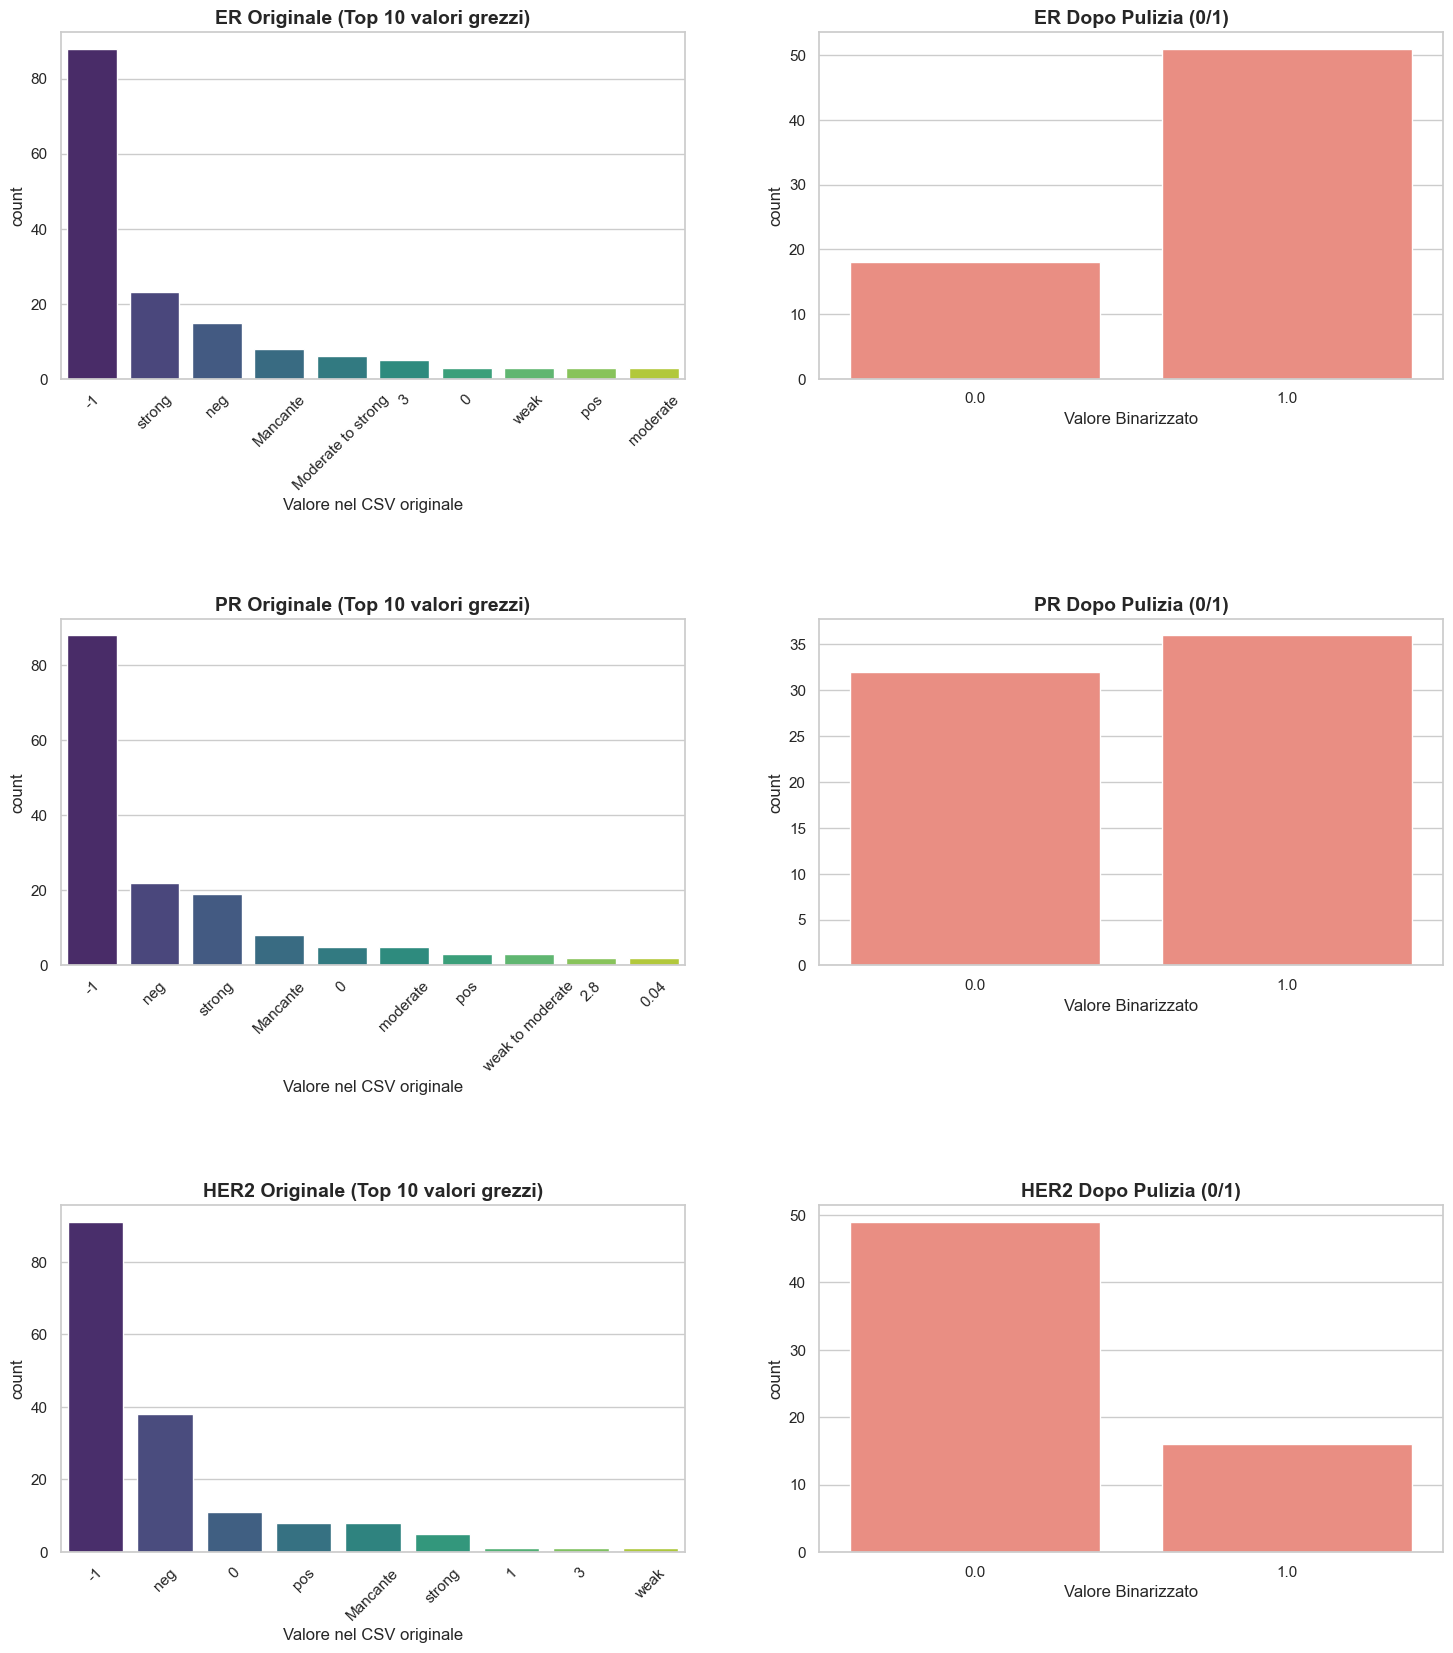

In [31]:
# 1. Caricamento
file_name = 'ambl_lesions_radiomic_medsam.csv' 
df_raw = pd.read_csv(DATASET_PATH / file_name)
print(f"1. Righe totali nel file originale: {len(df_raw)}")

# 2. Applicazione Filtro Maligni
df_clean = df_raw.copy()
if "tumor/benign" in df_clean.columns:
    # Usiamo astype(str) per evitare problemi tra 1 (int) e 1.0 (float)
    df_clean = df_clean[df_clean["tumor/benign"].astype(str).isin(['1', '1.0'])].copy()
    print(f"2. Righe dopo filtro 'tumor/benign == 1': {len(df_clean)}")

# 3. Trasformazione e Recupero IHC
for rec in ['ER', 'PR', 'HER2']:
    s_col, p_col = f'{rec} [SII]', f'{rec} [%]'
    
    if s_col in df_clean.columns:
        # Applichiamo la funzione IHC (assicurati che sia definita nelle celle precedenti)
        val_sii = df_clean[s_col].apply(standardizzazione_IHC)
        
        if p_col in df_clean.columns:
            val_perc = df_clean[p_col].apply(standardizzazione_IHC)
            df_clean[s_col] = val_sii.fillna(val_perc)
            
            n_recuperati = (val_sii.isna() & val_perc.notna()).sum()
            print(f"   -> {rec}: recuperati {n_recuperati} valori mancanti tramite la colonna %")
        else:
            df_clean[s_col] = val_sii

# 4. Verifica finale prima del grafico
print(f"3. Righe finali pronte per il grafico: {len(df_clean)}")

if len(df_clean) > 0:
    genera_report_e_grafici(df_raw, df_clean, file_name)
else:
    print("❌ ERRORE: Il dataset pulito è vuoto. Controlla il filtro 'tumor/benign'.")

df_clean.to_csv(OUTPUT_PATH / file_name, index=False)